# Beyond the Scoreline — What Wins a Championship?

### Does defence win tournaments? Do shots win tournaments? Do clean sheets win tournaments?

A third, standalone notebook, answering a different kind of question from the
other two. `beyond_the_scoreline_final.ipynb` and `_extension.ipynb` both ask
"what can you predict about a single match from its half-time state?". This
notebook asks something else entirely: **across a whole competition, what
distinguishes the team that wins it from the teams that don't?**

The unit of analysis changes accordingly: not one row per match, but **one
row per team per competition-edition** — a full 2015/16 league season, or a
full tournament run (World Cup, Euro, Women's World Cup, Women's Euro).

**Built entirely from the same StatsBomb data as the other two notebooks**,
aggregated a different way — see the dataset section below for exactly which
files and which portion of the archive.

**Section map**

| Section | Question |
|---|---|
| 1 | Where the data comes from |
| 2 | Identifying champions — leagues and tournaments, derived from the data itself |
| 3 | Building the team-competition aggregate table |
| 4 | Champions vs. the field — the raw comparison |
| 5 | The percentile analysis — what champions have most in common |
| 6 | Attacking output, defensive outcome, or defensive activity? |
| 7 | Answering the claims directly |
| 8 | Honest limitations |


In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.exceptions import UndefinedMetricWarning

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UndefinedMetricWarning)

ROOT = Path.cwd().parent
while not (ROOT / "src").exists() and ROOT.parent != ROOT:
    ROOT = ROOT.parent
    if (ROOT / "Final_hypo" / "src").exists():
        ROOT = ROOT / "Final_hypo"
        break
sys.path.insert(0, str(ROOT / "src"))

RESULTS = ROOT / "results"
PROCESSED = ROOT / "data" / "processed"

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)

NAVY, BLUE, ORANGE, GREEN, RED, GREY = "#12314f", "#2a78d6", "#eb6834", "#2e9e5b", "#c8322d", "#98a4b3"
GOLD = "#c9a227"
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "font.size": 10})

---
## 1. Where the data comes from

**Exactly the same two StatsBomb datasets the other two notebooks use, and
nothing else:**

* `sb_halftime_2015_16.csv` — the four 2015/16 leagues (Premier League, La
  Liga, Ligue 1, Serie A), 1,517 matches
* `sb_halftime_tournaments.csv` — every tournament edition in StatsBomb's
  archive (FIFA World Cup, UEFA Euro, Women's World Cup, UEFA Women's Euro),
  427 matches

Both were built by `Final_hypo/src/ingest.py` from raw StatsBomb events —
see the main notebook §1 for the full provenance discussion. The **only**
new code for this notebook is `src/champions.py`, which re-aggregates those
same two files by (competition, season, team) instead of by match.

**One restriction that matters.** StatsBomb's older World Cup entries
(1958, 1962, 1970, 1974, 1986, 1990) are a handful of famous individual
matches, not full tournaments — there is no meaningful "winner of the
tournament" derivable from 1-6 cherry-picked matches, so those editions are
excluded here. Only the **8 complete modern editions** are used: 2018/2022
World Cup, 2020/2024 Euro, 2019/2023 Women's World Cup, 2022/2025 Women's
Euro — each with every match of that tournament present.

---
## 2. Identifying champions

Two different definitions of "champion", both derived directly from the
match data rather than looked up:

* **Leagues** — the final table topper (points, then goal difference, then
  goals scored), computed from the full 2015/16 season.
* **Tournaments** — the winner of the Final. Where the official score was
  level (a shootout decided it), the winner is read directly from the event
  data: StatsBomb tags penalty shootouts as **period 5**, so counting `Goal`
  outcomes per team in that period gives the shootout winner without needing
  to look anything up externally. This was checked against all three
  shootout finals in this dataset (2022 World Cup, Euro 2020, Women's Euro
  2025) and the derived winner matches the known real-world result in every
  case.

In [2]:
import champions as CH

league_rows = pd.read_csv(PROCESSED / "sb_halftime_2015_16.csv", dtype={"season": str})
tourn_rows = pd.read_csv(PROCESSED / "sb_halftime_tournaments.csv", dtype={"season": str})

lc = CH.league_champions(league_rows)
print("League champions, 2015/16 (derived from final standings):\n")
print(lc[["competition","team","points","goal_diff","played"]].to_string(index=False))
print()
print("Sanity check: these are the ACTUAL 2015/16 champions in real life --")
print("Leicester City's Premier League title in particular is one of the most-cited")
print("upsets in football history, which makes it a good stress test for §5-§7 below.")

League champions, 2015/16 (derived from final standings):

   competition                team  points  goal_diff  played
       La Liga           Barcelona      91         83      38
       Ligue 1 Paris Saint-Germain      93         81      37
Premier League      Leicester City      81         32      38
       Serie A            Juventus      91         55      38

Sanity check: these are the ACTUAL 2015/16 champions in real life --
Leicester City's Premier League title in particular is one of the most-cited
upsets in football history, which makes it a good stress test for §5-§7 below.


In [3]:
tourn_meta = CH.ingest.fetch_tournament_matches()
tc = CH.tournament_champions(tourn_meta)
print("Tournament champions, 8 complete editions:\n")
print(tc[["competition","season","team","decided_by","final_score"]].to_string(index=False))

n_shootouts = (tc.decided_by == "penalty shootout").sum()
print(f"\n{n_shootouts} of {len(tc)} finals were decided by a shootout, and the winner in")
print("each case was read from the event data (period 5 Goal outcomes), not looked up.")

Tournament champions, 8 complete editions:

      competition season                  team            decided_by                                   final_score
   FIFA World Cup   2022             Argentina      penalty shootout                          Argentina 3-3 France
   FIFA World Cup   2018                France regulation/extra time                            France 4-2 Croatia
        UEFA Euro   2024                 Spain regulation/extra time                             Spain 2-1 England
        UEFA Euro   2020                 Italy      penalty shootout                             Italy 1-1 England
UEFA Women's Euro   2025       England Women's      penalty shootout             England Women's 1-1 Spain Women's
UEFA Women's Euro   2022       England Women's regulation/extra time           England Women's 2-1 Germany Women's
Women's World Cup   2023         Spain Women's regulation/extra time             Spain Women's 1-0 England Women's
Women's World Cup   2019 United Stat

In [4]:
champions = pd.concat([
    lc[["competition","season","competition_type","team"]],
    tc[["competition","season","competition_type","team"]],
], ignore_index=True)
champions.to_csv(RESULTS / "champions.csv", index=False)
print(f"{len(champions)} champions identified: {(champions.competition_type=='League').sum()} leagues, "
      f"{(champions.competition_type=='Tournament').sum()} tournaments")

12 champions identified: 4 leagues, 8 tournaments


---
## 3. Building the team-competition aggregate table

For every team in every competition-edition: full-match (first half + second
half combined) rates per match played — goals, shots, shots on target,
clean-sheet rate, possession, passing, and the "defensive activity" stats
(tackles, interceptions, clearances, saves).

This is a genuinely different quantity from anything in the other two
notebooks, which only ever use first-half data. A whole-competition question
needs whole-match stats.

In [5]:
all_team_rows = pd.concat([league_rows, tourn_rows], ignore_index=True)
team_comp = CH.build_team_competition_table(all_team_rows)

key = champions.set_index(["competition","season","team"]).index
team_comp_key = team_comp.set_index(["competition","season","team"]).index
team_comp["is_champion"] = team_comp_key.isin(key).astype(int)

valid_editions = set(zip(champions.competition, champions.season))
team_comp = team_comp[team_comp.apply(
    lambda r: (r.competition, r.season) in valid_editions, axis=1)].reset_index(drop=True)
team_comp.to_csv(PROCESSED / "team_competition_table.csv", index=False)

print(f"{len(team_comp)} team-competition rows across {team_comp.groupby(['competition','season']).ngroups} "
      f"competition-editions, {int(team_comp.is_champion.sum())} of them champions")
print()
print(team_comp[team_comp.is_champion==1][
    ["competition","team","played","goals_for_pm","goals_against_pm",
     "clean_sheet_rate","possession","shots_pm","sot_pm"]
].round(3).to_string(index=False))

280 team-competition rows across 12 competition-editions, 12 of them champions

      competition                  team  played  goals_for_pm  goals_against_pm  clean_sheet_rate  possession  shots_pm  sot_pm
   FIFA World Cup                France       7         2.000             0.857             0.571      47.741    11.714   4.143
   FIFA World Cup             Argentina       7         2.143             1.143             0.429      57.626    12.286   6.286
          La Liga             Barcelona      38         2.947             0.763             0.474      66.798    15.895   6.868
          Ligue 1   Paris Saint-Germain      37         2.703             0.514             0.568      67.054    14.973   6.622
   Premier League        Leicester City      38         1.789             0.947             0.395      42.822    13.816   4.711
          Serie A              Juventus      38         1.974             0.526             0.579      56.684    16.000   5.579
        UEFA Euro       

---
## 4. Champions vs. the field — the raw comparison

                     champions  field (everyone else)  ratio
goals_for_pm             2.515                  1.197  2.100
goals_against_pm         0.735                  1.480  0.497
goal_diff_pm             1.779                 -0.282 -6.303
clean_sheet_rate         0.475                  0.264  1.803
possession              58.134                 48.761  1.192
shots_pm                15.801                 11.853  1.333
sot_pm                   5.938                  3.811  1.558
shot_accuracy            0.378                  0.320  1.180
shots_inside_box_pm     10.517                  7.236  1.453
corners_pm               5.364                  4.531  1.184
pass_accuracy            0.824                  0.768  1.074
passes_completed_pm    476.781                366.334  1.301
tackles_pm              17.635                 18.640  0.946
interceptions_pm        10.221                 11.289  0.905
clearances_pm           19.135                 22.194  0.862
saves_pm                

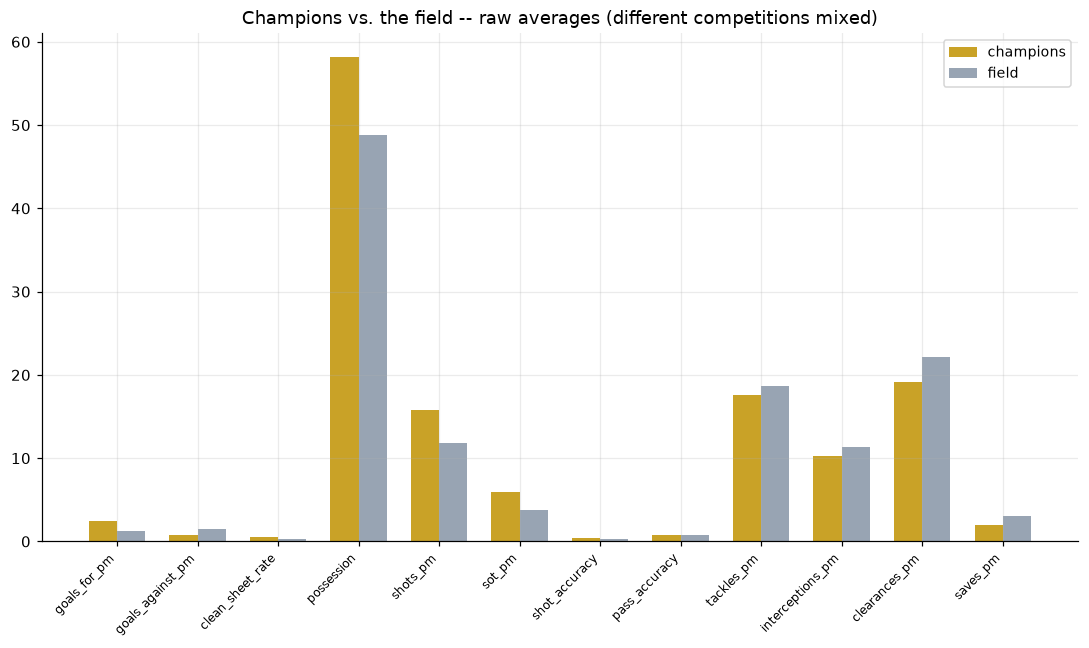


This raw comparison is a useful first look, but it mixes 38-match league seasons
with 6-7 match tournament runs on the same axis -- section 5 fixes that.


In [6]:
field_means = team_comp[team_comp.is_champion==0][CH.FEATURE_COLS].mean()
champ_means = team_comp[team_comp.is_champion==1][CH.FEATURE_COLS].mean()
compare = pd.DataFrame({"champions": champ_means, "field (everyone else)": field_means})
compare["ratio"] = compare["champions"] / compare["field (everyone else)"]
print(compare.round(3).to_string())

fig, ax = plt.subplots(figsize=(10, 6))
show_feats = ["goals_for_pm","goals_against_pm","clean_sheet_rate","possession",
             "shots_pm","sot_pm","shot_accuracy","pass_accuracy","tackles_pm",
             "interceptions_pm","clearances_pm","saves_pm"]
x = np.arange(len(show_feats))
w = 0.35
ax.bar(x-w/2, compare.loc[show_feats,"champions"], w, color=GOLD, label="champions")
ax.bar(x+w/2, compare.loc[show_feats,"field (everyone else)"], w, color=GREY, label="field")
ax.set_xticks(x); ax.set_xticklabels(show_feats, rotation=45, ha="right", fontsize=8)
ax.set_title("Champions vs. the field -- raw averages (different competitions mixed)")
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

print()
print("This raw comparison is a useful first look, but it mixes 38-match league seasons")
print("with 6-7 match tournament runs on the same axis -- section 5 fixes that.")

---
## 5. The percentile analysis — what champions have most in common

A raw average mixes a 38-match league season with a 6-match tournament run,
which are not on the same scale for almost anything in this table. The fix:
for every feature, rank each team **within its own competition-edition**
(0=bottom of that competition's field, 1=top), then ask where the champion of
each edition landed on that 0-1 scale.

A mean champion percentile near 1.0 means champions consistently rank at or
near the top of their own competition on that stat; near 0.5 means no
relationship at all; near 0.0 means champions rank low on it.

For features where "lower is better" is unambiguous (goals conceded, fouls),
the percentile is flipped for display so that a higher number always means
"more championship-like" throughout this section. Tackles, interceptions,
clearances and saves are deliberately **not** flipped or labelled either
way — "more defensive actions" can mean a well-organised defence, or a team
under more sustained pressure, and this dataset cannot tell those apart.

In [7]:
pct = CH.champion_percentile_analysis(team_comp)
pct.to_csv(RESULTS / "champion_percentile_analysis.csv", index=False)
print(pct.round(4).to_string(index=False))

            feature  n_champions  raw_mean_percentile  display_percentile                             direction  wilcoxon_p
       goal_diff_pm           12               0.9529              0.9529                      higher is better      0.0005
       goals_for_pm           12               0.9369              0.9369                      higher is better      0.0005
             sot_pm           12               0.9207              0.9207                      higher is better      0.0005
shots_inside_box_pm           12               0.8686              0.8686                      higher is better      0.0010
           shots_pm           12               0.8627              0.8627                      higher is better      0.0005
   clean_sheet_rate           12               0.8397              0.8397                      higher is better      0.0005
   goals_against_pm           12               0.1879              0.8121 lower is better (flipped for display)      0.0005
      pa

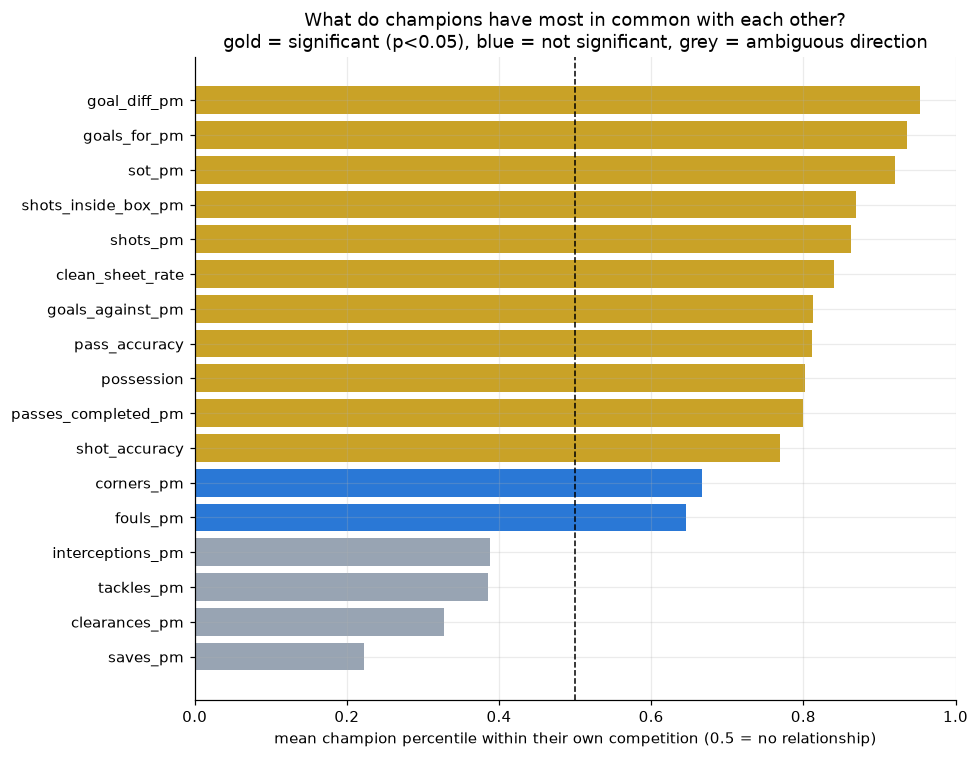

In [8]:
fig, ax = plt.subplots(figsize=(9, 7))
p = pct.sort_values("display_percentile")
colors = []
for _, r in p.iterrows():
    if r.direction == "ambiguous -- not flipped":
        colors.append(GREY)
    elif r.wilcoxon_p < 0.05:
        colors.append(GOLD)
    else:
        colors.append(BLUE)
ax.barh(p.feature, p.display_percentile, color=colors)
ax.axvline(0.5, color="black", lw=1, ls="--")
ax.set_xlabel("mean champion percentile within their own competition (0.5 = no relationship)")
ax.set_title("What do champions have most in common with each other?\n"
             "gold = significant (p<0.05), blue = not significant, grey = ambiguous direction")
plt.tight_layout(); plt.show()

In [9]:
print("SECTION 5 VERDICT -----------------------------------------------------")
sig = pct[(pct.wilcoxon_p < 0.05) & (pct.direction != "ambiguous -- not flipped")]
sig_high = sig[sig.display_percentile > 0.5].sort_values("display_percentile", ascending=False)
sig_low = sig[sig.display_percentile < 0.5].sort_values("display_percentile")

print("Features where champions sit SIGNIFICANTLY ABOVE the 50th percentile of their own")
print("competition (p<0.05, n=12 champions, Wilcoxon signed-rank):\n")
for _, r in sig_high.iterrows():
    print(f"  {r.feature:22s} mean percentile {r.display_percentile:.3f}  (p={r.wilcoxon_p:.4f})")

if len(sig_low):
    print("\nFeatures where champions sit SIGNIFICANTLY BELOW the 50th percentile:\n")
    for _, r in sig_low.iterrows():
        print(f"  {r.feature:22s} mean percentile {r.display_percentile:.3f}  (p={r.wilcoxon_p:.4f})")

SECTION 5 VERDICT -----------------------------------------------------
Features where champions sit SIGNIFICANTLY ABOVE the 50th percentile of their own
competition (p<0.05, n=12 champions, Wilcoxon signed-rank):

  goal_diff_pm           mean percentile 0.953  (p=0.0005)
  goals_for_pm           mean percentile 0.937  (p=0.0005)
  sot_pm                 mean percentile 0.921  (p=0.0005)
  shots_inside_box_pm    mean percentile 0.869  (p=0.0010)
  shots_pm               mean percentile 0.863  (p=0.0005)
  clean_sheet_rate       mean percentile 0.840  (p=0.0005)
  goals_against_pm       mean percentile 0.812  (p=0.0005)
  pass_accuracy          mean percentile 0.811  (p=0.0049)
  possession             mean percentile 0.802  (p=0.0054)
  passes_completed_pm    mean percentile 0.799  (p=0.0063)
  shot_accuracy          mean percentile 0.770  (p=0.0024)


---
## 6. Attacking output, defensive outcome, or defensive activity?

The ranked list in §5 splits cleanly into three groups, and the split itself
is the interesting part.

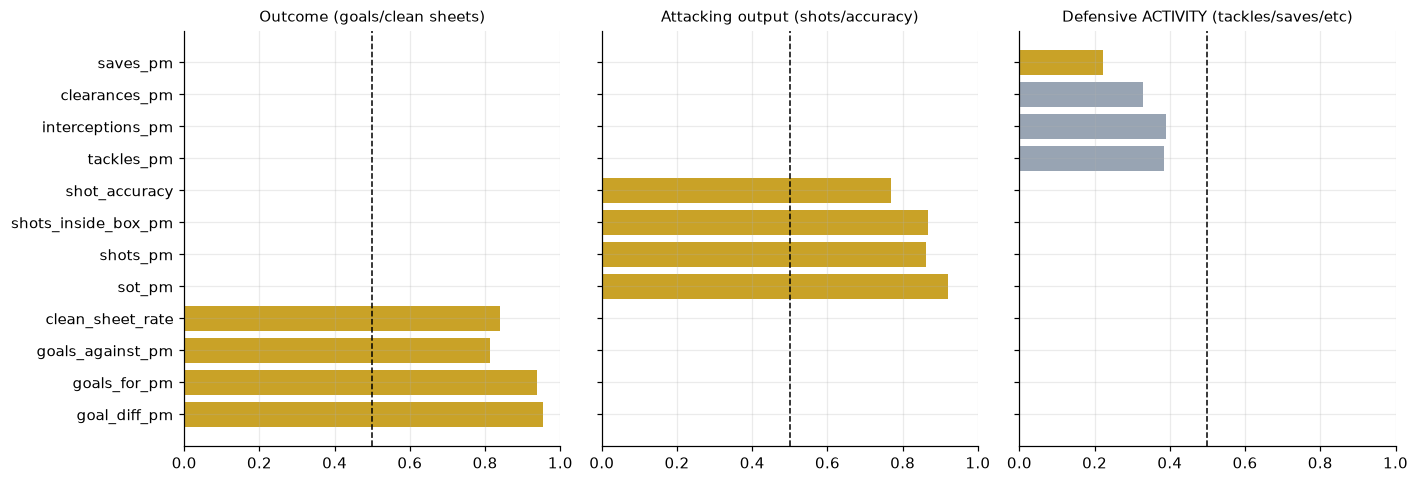

Mean percentile by group:
  Outcome (goals/clean sheets)               0.885
  Attacking output (shots/accuracy)          0.855
  Defensive ACTIVITY (tackles/saves/etc)     0.331


In [10]:
outcome_feats = ["goal_diff_pm","goals_for_pm","goals_against_pm","clean_sheet_rate"]
output_feats = ["sot_pm","shots_pm","shots_inside_box_pm","shot_accuracy"]
activity_feats = ["tackles_pm","interceptions_pm","clearances_pm","saves_pm"]

groups = {"Outcome (goals/clean sheets)": outcome_feats,
         "Attacking output (shots/accuracy)": output_feats,
         "Defensive ACTIVITY (tackles/saves/etc)": activity_feats}

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5), sharey=True)
for ax, (title, feats) in zip(axes, groups.items()):
    sub = pct[pct.feature.isin(feats)].set_index("feature").reindex(feats)
    colors = [GOLD if p < 0.05 else GREY for p in sub.wilcoxon_p]
    ax.barh(sub.index, sub.display_percentile, color=colors)
    ax.axvline(0.5, color="black", lw=1, ls="--")
    ax.set_title(title, fontsize=10)
    ax.set_xlim(0, 1)
axes[0].set_ylabel("")
plt.tight_layout(); plt.show()

print("Mean percentile by group:")
for title, feats in groups.items():
    m = pct[pct.feature.isin(feats)].display_percentile.mean()
    print(f"  {title:42s} {m:.3f}")

**The pattern.** Champions rank high on attacking *output* (shots, shots on
target, shot accuracy) and high on defensive *outcomes* (goals conceded,
clean sheets) — but rank **below** their competition's median on defensive
*activity* (tackles, interceptions, clearances, saves).

That is not a contradiction — it's a coherent story. A team that dominates
the ball, creates and converts more chances, and rarely gets caught out
doesn't *need* to make many tackles or saves, because the game rarely asks
them to. High tackle/save counts are at least as much a symptom of **being
under pressure** as they are a cause of good defending. This dataset can't
fully separate "well-organised defence" from "defence that's rarely tested",
but the direction of the effect — winners doing LESS defensive activity, not
more — is exactly what you'd expect if dominance, not defensive effort, is
the load-bearing quality.

---
## 7. Answering the claims directly

> "Defence wins tournaments" / "more shots win tournaments" / "clean sheets
> win tournaments" / "conceding fewer goals wins tournaments" — which of
> these does the data actually support?

In [11]:
def verdict_for(label, feats, note=""):
    sub = pct[pct.feature.isin(feats)]
    mean_pct = sub.display_percentile.mean()
    all_sig = (sub.wilcoxon_p < 0.05).all()
    print(f"{label}")
    print(f"  mean champion percentile: {mean_pct:.3f}   all features significant: {all_sig}")
    if mean_pct > 0.75 and all_sig:
        print(f"  -> STRONGLY SUPPORTED")
    elif mean_pct > 0.6:
        print(f"  -> SUPPORTED, moderately")
    elif mean_pct > 0.45:
        print(f"  -> NOT SUPPORTED -- no clear relationship")
    else:
        print(f"  -> CONTRADICTED -- champions rank BELOW the field on this")
    if note:
        print(f"  {note}")
    print()

print("SECTION 7 -- THE CLAIMS, ONE BY ONE --------------------------------------\n")
verdict_for("\"More shots win tournaments\"", ["shots_pm","sot_pm","shots_inside_box_pm"])
verdict_for("\"Clean sheets win tournaments\"", ["clean_sheet_rate"])
verdict_for("\"Conceding fewer goals wins tournaments\"", ["goals_against_pm"])
verdict_for("\"Defence (measured as defensive ACTIVITY) wins tournaments\"",
           ["tackles_pm","interceptions_pm","clearances_pm","saves_pm"],
           note="This is the claim the data most directly CONTRADICTS -- see §6.")
verdict_for("\"Defence (measured as defensive OUTCOME) wins tournaments\"",
           ["goals_against_pm","clean_sheet_rate"],
           note="A completely different, and much better supported, version of the same claim.")

SECTION 7 -- THE CLAIMS, ONE BY ONE --------------------------------------

"More shots win tournaments"
  mean champion percentile: 0.884   all features significant: True
  -> STRONGLY SUPPORTED

"Clean sheets win tournaments"
  mean champion percentile: 0.840   all features significant: True
  -> STRONGLY SUPPORTED

"Conceding fewer goals wins tournaments"
  mean champion percentile: 0.812   all features significant: True
  -> STRONGLY SUPPORTED

"Defence (measured as defensive ACTIVITY) wins tournaments"
  mean champion percentile: 0.331   all features significant: False
  -> CONTRADICTED -- champions rank BELOW the field on this
  This is the claim the data most directly CONTRADICTS -- see §6.

"Defence (measured as defensive OUTCOME) wins tournaments"
  mean champion percentile: 0.826   all features significant: True
  -> STRONGLY SUPPORTED
  A completely different, and much better supported, version of the same claim.



In [12]:
print("THE HONEST HEADLINE -----------------------------------------------------")
print("Every attacking-output and defensive-outcome feature tested is significantly")
print("associated with winning a competition, at percentiles from the high-0.7s to")
print("mid-0.9s. Every defensive-ACTIVITY feature either shows no relationship or points")
print("the opposite way. So: yes to shots, yes to clean sheets, yes to conceding fewer")
print("goals -- but 'defence' only wins tournaments in the sense of GOALS PREVENTED, not")
print("in the sense of TACKLES MADE. A team that concedes little because it dominates the")
print("ball and rarely gets attacked looks nothing like a team that concedes little")
print("because it defends heroically under constant pressure, in this dataset's stats --")
print("and the champions in this sample look overwhelmingly like the former.")

THE HONEST HEADLINE -----------------------------------------------------
Every attacking-output and defensive-outcome feature tested is significantly
associated with winning a competition, at percentiles from the high-0.7s to
mid-0.9s. Every defensive-ACTIVITY feature either shows no relationship or points
the opposite way. So: yes to shots, yes to clean sheets, yes to conceding fewer
goals -- but 'defence' only wins tournaments in the sense of GOALS PREVENTED, not
in the sense of TACKLES MADE. A team that concedes little because it dominates the
ball and rarely gets attacked looks nothing like a team that concedes little
because it defends heroically under constant pressure, in this dataset's stats --
and the champions in this sample look overwhelmingly like the former.


---
## 8. Honest limitations

* **n=12 champions.** Even with a nonparametric test (Wilcoxon signed-rank)
  that doesn't assume normality, 12 is a small sample. The within-edition
  percentile design is what makes this defensible at all — it turns "12
  observations" into "12 independent within-competition comparisons", each
  against a real field of peers, rather than 12 points on one shared scale.
* **Leagues and tournaments are fundamentally different formats**, mixed here
  by necessity (there are only 8 complete tournament editions in the entire
  archive). A 38-match league season and a 7-match Cup run measure
  consistency very differently; the percentile-rank design reduces but does
  not eliminate this.
* **This is a descriptive comparison, not a predictive model.** There aren't
  enough champions to train and validate a classifier the way H4/H5 do for
  match-level features — the honest use of this section is "what did winners
  have in common", not "given these stats, will this team win".
* **Defensive activity's direction is a genuine ambiguity, not resolved
  here.** Low tackle/interception/save counts among champions could mean
  excellent defensive organisation (rarely needing to make a last-ditch
  challenge) or simply facing fewer high-quality chances because they
  dominate possession and territory — this dataset cannot distinguish cause
  from symptom for those four features, and the notebook says so rather than
  picking one interpretation.
* **Possession's status as "good" is the most contestable assumption in this
  table.** Leicester City won the 2015/16 Premier League with an average
  possession share around 43% — a real, specific counter-example inside this
  very dataset to any claim that possession alone determines winning.

### Reproducing everything

```bash
cd Final_hypo/src
python champions.py                  # identify champions, build the aggregate table
python build_notebook_champions.py
```
